# Certifying T-count lower bounds with MITM

In fault-tolerant quantum computing, not every gate costs the same. The Clifford group (gates like $H$, $S$, $CNOT$) can typically be implemented relatively cheaply. The $T$ gate is

$$T = \begin{bmatrix} 1 & 0 \\ 0 & e^{i\pi/4} \end{bmatrix}.$$

Each $T$ usually consumes a distilled magic state, which dominates the qubit and time budget of a fault-tolerant machine. So when you implement a bigger gate (Toffoli, CCZ, controlled-$S$, and so on) out of Clifford and $T$ pieces, the number of $T$ gates — the **T-count** — is a useful cost proxy.

This notebook is a small, fully runnable certification. We take controlled-$S$ on two qubits, show that nullity only forces T-count $\ge 2$, then use search to rule out $t \le 2$ and find a witness at $t = 3$. The same style of argument is what settles CCZ / Toffoli / Fredkin at $4$ in a separate BlueQubit experiment, though we do not re-run those cluster jobs here.

## 0. Setup

Code uses the small `t-gates-mitm` package (`tgates_mitm`) in this folder, plus Qiskit/Matplotlib to draw witness circuits. From this directory:

```bash
pip install -e ".[dev]"
pip install qiskit matplotlib
```

On a BlueQubit hosted notebook these are expected to be preinstalled.


In [1]:
# From this folder: pip install -e ".[dev]" && pip install qiskit matplotlib
import time

import numpy as np

from tgates_mitm import (
    adaptive_lower_bound_ccz,
    build_choi_state,
    ccz_4t,
    ccz_target,
    count_t_gates,
    decide_meas_tcount_leq,
    mitm_decide_leq,
    state_stabilizer_nullity,
    unitary_stabilizer_nullity,
    verify_adaptive_channel,
)
from tgates_mitm.gates import ccz_matrix
from tgates_mitm.synthesis import (
    CliffordChecker,
    SignedPauli,
    parse_signed_label,
    rotation_for,
    signed_paulis,
)

import tgates_mitm

print("tgates_mitm", getattr(tgates_mitm, "__version__", "0.1.0"))


tgates_mitm 0.1.0


## 1. Three models of implementing a gate

Before counting $T$ gates, you have to say what kind of circuit is allowed. Three nested settings matter here.

### 1.1 Unitary Clifford+T

The classical setting: a circuit of Clifford gates and $T$ / $T^\dagger$ only, no measurement, no extra workspace that you throw away. The output is a unitary matrix $U$ on the data qubits. The **unitary T-count** is the least number of $T$-type gates in any such circuit for $U$ (up to the usual global-phase conventions used in the literature).

This is the most naive setting and often gives the largest T-count.

### 1.2 Measurement-assisted circuits

A real fault-tolerant compiler also has:

- **ancillas**: extra qubits prepared in $|0\rangle$;
- mid-circuit $Z$ measurement;
- **classical feedforward**: later Clifford gates that depend on earlier measurement bits.

Rules of the game: unmeasured ancillas must return to $|0\rangle$ (disentangled from the data); measured ancillas are discarded. What the data qubits see is then a **quantum channel** (a completely positive map), not necessarily a unitary written as a single matrix on those wires alone.

Jones showed that with one ancilla and measurement, Toffoli / CCZ drop from unitary T-count $7$ down to $4$. That is why the measurement-assisted model is the one compilers care about: it is closer to what you can actually run.

Write $T_{\mathrm{meas}}(G, n_a)$ for the least T-count of a measurement-assisted circuit that implements gate $G$ using $n_a$ ancillas.

### 1.3 The all-measurements-at-end family

Every possible measurement-assisted circuit is an enormous search space (measurements and feedforward can appear anywhere). To get a machine-checked lower bound, the experiment restricts to an explicit finite subfamily that still contains every published construction for the gates of interest.

That subfamily is written $\mathcal{N}(n_a)$ and called the **all-measurements-at-end** family. A circuit in $\mathcal{N}(n_a)$ has three stages only:

1. Apply $t$ Pauli $\pi/8$ rotations $R(P_1),\ldots,R(P_t)$, where $R(P) = \exp(-i\pi P/8)$.
2. Measure the $n_a$ ancillas once, at the end.
3. Apply a Clifford on the data that depends on the measurement outcome bits.

In symbols:

$$R(P_1) R(P_2) \cdots R(P_t) \;\rightarrow\; \text{measure ancillas} \;\rightarrow\; \text{outcome-dependent Clifford}.$$

Each $R(P)$ is the form every $T$ takes after you absorb intervening Cliffords into the Pauli $P$. There are no $T$ gates after the measurement, and no interleaved measure–correct–measure patterns outside this template.

Write $T_{\mathrm{meas}}^{\mathcal{N}}(G, n_a)$ for the least T-count inside this family. Always

$$T_{\mathrm{meas}}(G, n_a) \le T_{\mathrm{meas}}^{\mathcal{N}}(G, n_a),$$

because $\mathcal{N}(n_a)$ is a subset of all measurement-assisted circuits. A lower bound proved inside $\mathcal{N}$ becomes a lower bound on the wider model only after you argue the family is complete enough (the writeup treats that carefully). What the search itself proves, with no extra hypothesis, is:

if no circuit in $\mathcal{N}(n_a)$ uses at most $t$ gates of type $T$, then $T_{\mathrm{meas}}^{\mathcal{N}}(G, n_a) > t$.

Why bother with this restriction? Because it is searchable, it contains the known optimal constructions (Jones 4-$T$ CCZ, Gidney–Jones 6-$T$ CCCZ, and so on), and a negative result inside it is still a theorem about that family.

## 2. How we report a bound

We never quote a single integer without saying which half it came from.

| Half | Meaning |
|------|---------|
| Lower bound | Larger of (i) stabilizer nullity of the Choi state and (ii) one plus the largest $t$ ruled out by exhaustive search in $\mathcal{N}(n_a)$ |
| Upper bound | T-count of an explicit circuit that has been re-checked as an exact channel (phases included) |

If the lower bound equals the upper bound, the T-count is settled. If not, you have a gap (for example CCCZ sits in $[4,6]$ in the general picture).

Nullity is cheap algebra. Closing gaps usually needs search.

## 3. Stabilizer nullity (what it is, and what it is not)

### 3.1 Stabilizer states, in one paragraph

A pure state $|\psi\rangle$ on $n$ qubits is a **stabilizer state** if it is uniquely fixed by $n$ independent Pauli operators $P_1,\ldots,P_n$ with $P_j |\psi\rangle = |\psi\rangle$ (the stabilizer generators). Computational basis states, graph states, and anything you can reach from $|0\rangle^{\otimes n}$ by Clifford gates alone are stabilizer states. They are Clifford-cheap: you can prepare them without $T$ gates.

### 3.2 Nullity as how non-Clifford this is

**Stabilizer nullity** (Beverland–Campbell–Howard–Kliuchnikov) is a number $\nu$ attached to a state (or, via the Choi state, to a channel / unitary). Roughly:

- If $|\psi\rangle$ is a stabilizer state on $n$ qubits, its nullity is $0$.
- Each independent $T$-type resource can increase nullity by at most $1$.
- Therefore $\nu$ is a lower bound on the number of $T$ gates needed to prepare that state (or implement that channel), even if you are allowed ancillas, measurement, and feedforward.

For a unitary $U$ on $n$ qubits, one concrete formula (what `unitary_stabilizer_nullity` computes) is

$$\nu(U) = 2n - \log_2(k),$$

where $k$ is how many Pauli matrices $P$ satisfy: $U P U^\dagger$ is again a Pauli, up to a phase in $\{+1,-1,+i,-i\}$.

Clifford gates permute Paulis among themselves, so $k = 4^n$ and $\nu = 0$. Each $T$ can shrink $k$. Nullity never builds a circuit; it only forbids too-cheap ones.

Another common route is to form the **Choi state** of $U$ (apply $U$ to half of a maximally entangled pair) and compute that state's stabilizer nullity. For the gates below, both routes agree.

### 3.3 Worked example: one-qubit $I$, $S$, and $T$

On one qubit there are four Pauli matrices $\{I,X,Y,Z\}$, so $2n = 2$. For each candidate Pauli $P$, check whether $U P U^\dagger$ equals a Pauli up to phase.

**Identity (and any Clifford, e.g. $S$ or $H$).** Conjugation by a Clifford sends Paulis to Paulis, so all four survive:

$$\nu(I) = 2 - \log_2 4 = 2 - 2 = 0.$$

Same for $S = \mathrm{diag}(1,i)$: it is Clifford, so $\nu(S) = 0$. That matches the slogan "Clifford is free."

**The $T$ gate.** $T = \mathrm{diag}(1, e^{i\pi/4})$. Conjugation still fixes $I$ and $Z$ (they are diagonal in the same basis), but $T X T^\dagger$ and $T Y T^\dagger$ are not Paulis up to phase. Only two Paulis survive, so

$$\nu(T) = 2 - \log_2 2 = 2 - 1 = 1.$$

So nullity already forces the T-count of $T$ to be at least $1$, which is tight: one $T$ gate implements $T$.

The next cell computes these numbers with the library.

### 3.4 Why it is often loose

Nullity can under-shoot the true T-count. Controlled-$S$ has nullity $2$ but true unitary T-count $3$. CCZ has nullity $3$ but measurement-assisted optimum $4$. So nullity is a fast first cut; proving optimality usually needs an exhaustive rule-out on top.


In [41]:
import math

from tgates_mitm.gates import SINGLE, all_pauli_matrices, is_pauli_up_to_phase

I = np.eye(2, dtype=complex)
S = SINGLE['s']
T = SINGLE['t']
paulis = all_pauli_matrices(1)


def count_preserved(u):
    # How many Paulis P have U P U^dag equal to a Pauli up to phase.
    udag = u.conj().T
    return sum(1 for p in paulis if is_pauli_up_to_phase(u @ p @ udag, paulis))


for name, u in [('I', I), ('S', S), ('T', T)]:
    k = count_preserved(u)
    nu = 2 - math.log2(k)
    lib = unitary_stabilizer_nullity(u, 1)
    print(f'{name}: k={k} preserved Paulis  =>  nu = 2 - log2(k) = {nu:.0f}  (library: {lib})')

print()
print('Sanity: Clifford => nu=0; single T => nu=1.')


I: k=4 preserved Paulis  =>  nu = 2 - log2(k) = 0  (library: 0.0)
S: k=4 preserved Paulis  =>  nu = 2 - log2(k) = 0  (library: 0.0)
T: k=2 preserved Paulis  =>  nu = 2 - log2(k) = 1  (library: 1.0)

Sanity: Clifford => nu=0; single T => nu=1.


## 4. Running example: controlled-$S$

Controlled-$S$ is the two-qubit diagonal unitary

$$\mathrm{CS} = \mathrm{diag}(1,1,1,i).$$

It applies an $S$ phase to the target when the control is $|1\rangle$. Its unitary T-count is a known answer of $3$: small enough for a laptop, large enough that nullity does not finish the proof alone.

In [42]:
CS = np.diag([1, 1, 1, 1j]).astype(complex)
N = 2

u_null = unitary_stabilizer_nullity(CS, N)
choi = build_choi_state(CS, N)
choi_null, n_stab = state_stabilizer_nullity(choi, 2 * N)

print(f"controlled-S unitary stabilizer nullity : {u_null}")
print(f"controlled-S Choi stabilizer nullity    : {choi_null}  ({n_stab} stabilizers)")
print()
print("Nullity alone only forces T-count >= 2.")
print("Closing the gap to 3 needs exhaustive rule-out of t <= 2.")

controlled-S unitary stabilizer nullity : 2.0
controlled-S Choi stabilizer nullity    : 2.0  (4 stabilizers)

Nullity alone only forces T-count >= 2.
Closing the gap to 3 needs exhaustive rule-out of t <= 2.


## 5. Meet-in-the-middle (unitary MITM)

### 5.1 Why T-count reduces to a Pauli-rotation search

A $T$ gate on one qubit is $T = \mathrm{diag}(1, e^{i\pi/4})$. In the Clifford+$T$ gate set you never need "$T$ on qubit $j$" as a special case: conjugating by Cliffords moves $T$ around. Concretely, for any Clifford $C$ and any Pauli $P$ with $P^2 = I$,

$$C\, T\, C^\dagger = R(P) := \exp\bigl(-i \tfrac{\pi}{8} P\bigr)$$

for a suitable Pauli $P$ (or $T^\dagger$ gives the opposite sign). So every $T$ / $T^\dagger$ that appears in a circuit is, after absorbing the Cliffords around it, just a **Pauli $\pi/8$ rotation**.

That gives the normal form used by Amy–Maslov–Mosca–Roetteler and Gosset–Kliuchnikov–Mosca–Russo: a unitary $U$ has (unitary) T-count at most $t$ if and only if there exist Paulis $P_1,\ldots,P_t$ such that

$$U\, R(-P_t)\cdots R(-P_1)$$

is a Clifford matrix. Equivalently,

$$U = C\, R(P_1)\cdots R(P_t)$$

for some Clifford $C$. The Cliffords that used to sit *between* the $T$ gates have been absorbed into the choice of each $P_j$. The only numerical checks left are "multiply by $R(P)$" and "is this matrix Clifford?".

### 5.2 Why brute force hurts, and what MITM saves

On $n$ qubits there are $4^n$ Pauli strings, or $N_P = 2(4^n - 1)$ if you include an overall $\pm$ sign and drop the identity (what this library enumerates). A naive search tries every length-$t$ sequence:

$$\text{cost} \sim N_P^t.$$

Examples:

- $n=2$: $N_P = 30$, so $t=3$ is $30^3 = 27{,}000$ products (easy).
- $n=3$: $N_P = 126$, so $t=3$ is $126^3 \approx 2\times 10^6$, and $t=4$ is already $\sim 2.5\times 10^8$.

**Meet-in-the-middle** splits a length-$t$ product into a forward half of length $a = \lceil t/2\rceil$ and a backward half of length $b = t-a$:

1. Build a hash table of all forward products, keyed by the *left-Clifford coset* of their channel matrix (so $C\cdot M$ and $M$ share a key).
2. For each backward product $B$, look up whether $U B^\dagger$ hits a forward key.
3. Every hash hit is only a candidate: recompute the residual and test "is Clifford?" exactly. That removes false accepts.

Cost drops to about $N_P^{\lceil t/2\rceil}$ table builds / probes instead of $N_P^t$. Failure at every $t' \le t$ is a rigorous lower bound; success gives an upper bound **and** an explicit list of signed Paulis (a witness).

`mitm_decide_leq(U, t, n)` is that decision procedure. We run it on controlled-$S$ next, then turn the witness into a Qiskit circuit.


In [43]:
print("Unitary MITM on controlled-S")
print("-" * 40)
print(f"N_P (n=2 signed non-identity Paulis) = {len(signed_paulis(2))}")
print()

CS_WITNESS = None
for t in (0, 1, 2, 3):
    t0 = time.perf_counter()
    res = mitm_decide_leq(CS, t, N, show_progress=False)
    dt = time.perf_counter() - t0
    status = "FOUND" if res.found else "ruled out"
    print(f"  t <= {t}: {status:10s}  ({dt:.3f}s)")
    if res.found and res.witness is not None:
        CS_WITNESS = res.witness
        print(f"           witness rotations: {CS_WITNESS}")

assert CS_WITNESS is not None
assert not mitm_decide_leq(CS, 2, N, show_progress=False).found
print()
print("Verdict: unitary T-count(controlled-S) = 3")
print("(nullity 2 + MITM rules out t<=2 + witness at t=3)")


Unitary MITM on controlled-S
----------------------------------------
N_P (n=2 signed non-identity Paulis) = 30

  t <= 0: ruled out   (0.001s)
  t <= 1: ruled out   (0.007s)
  t <= 2: ruled out   (0.012s)
  t <= 3: FOUND       (0.113s)
           witness rotations: ['+1ZI', '+1ZZ', '+1IZ']

Verdict: unitary T-count(controlled-S) = 3
(nullity 2 + MITM rules out t<=2 + witness at t=3)


### 5.3 From witness to a Clifford+$T$ circuit

The witness is a list of signed Pauli labels. The normal form says

$$\mathrm{CS} = C\, R(P_1) R(P_2) R(P_3),$$

with each $R(P) = \exp(-i\pi P/8)$. Every such rotation is exactly Clifford+$T$: change basis so $P$ becomes a $Z$-string, apply $T$ or $T^\dagger$ (with CNOTs if several qubits), then undo the basis change. The residual $C$ is synthesized with Qiskit's Clifford compiler into $\{H,S,Z,\mathrm{CX}\}$.

The next cell builds that gate-level circuit, checks it against $\mathrm{CS}$ up to global phase, and draws it with Matplotlib.


witness: ['+1ZI', '+1ZZ', '+1IZ']
gate set: ['cx', 'h', 's', 't', 'z']
ops: {'cx': 3, 't': 3, 'z': 2, 's': 2, 'h': 2}
matches CS up to global phase: True


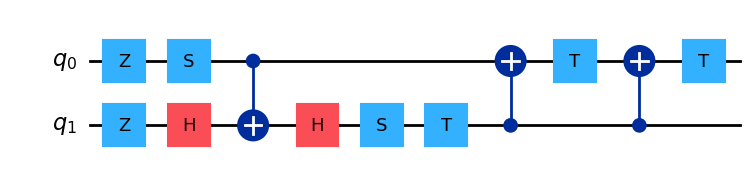

In [44]:
import warnings

warnings.filterwarnings("ignore", message=".*splu converted.*")
warnings.filterwarnings("ignore", message=".*spsolve is more efficient.*")
warnings.filterwarnings("ignore", message=".*limited charset.*")

from qiskit import QuantumCircuit
from qiskit.quantum_info import Clifford, Operator

assert CS_WITNESS is not None, "Run the MITM cell above first."


def r_pauli_as_clifford_t(pauli: str, sign: int) -> QuantumCircuit:
    # Exact R(sign*P)=exp(-i*pi/8*sign*P) with H,S,Sdg,CX,T,Tdg only.
    # tgates label[i] is tensor factor i (leftmost=high wire) -> Qiskit qubit n-1-i.
    n = len(pauli)

    def qiskit_qubit(i: int) -> int:
        return n - 1 - i

    qc = QuantumCircuit(n)
    for i, p in enumerate(pauli):
        qi = qiskit_qubit(i)
        if p == "X":
            qc.h(qi)
        elif p == "Y":
            qc.sdg(qi)
            qc.h(qi)

    support = [qiskit_qubit(i) for i, p in enumerate(pauli) if p != "I"]
    if support:
        if len(support) == 1:
            (qc.t if sign >= 0 else qc.tdg)(support[0])
        else:
            root = support[0]
            for j in support[1:]:
                qc.cx(root, j)
            (qc.t if sign >= 0 else qc.tdg)(support[-1])
            for j in reversed(support[1:]):
                qc.cx(root, j)

    for i in range(n - 1, -1, -1):
        p = pauli[i]
        qi = qiskit_qubit(i)
        if p == "X":
            qc.h(qi)
        elif p == "Y":
            qc.h(qi)
            qc.s(qi)
    return qc


def matches_up_to_global_phase(a: np.ndarray, b: np.ndarray, atol: float = 1e-8) -> bool:
    idx = int(np.argmax(np.abs(b)))
    phase = a.flat[idx] / b.flat[idx]
    return bool(np.allclose(a, b * phase, atol=atol))


rot_prod = np.eye(4, dtype=complex)
qc_rots = QuantumCircuit(2)
for lab in CS_WITNESS:
    sign, pauli = parse_signed_label(lab)
    rot_prod = rot_prod @ rotation_for(SignedPauli(pauli, sign))
    qc_rots.compose(r_pauli_as_clifford_t(pauli, sign), inplace=True)

C = CS @ rot_prod.conj().T
assert CliffordChecker(2).is_clifford(C)

qc = QuantumCircuit(2, name="CS_from_MITM_witness")
qc.compose(Clifford.from_matrix(C).to_circuit(), inplace=True)
qc.compose(qc_rots, inplace=True)

ok = matches_up_to_global_phase(Operator(qc).data, CS)
gate_set = sorted({inst.operation.name for inst in qc.data})

print("witness:", CS_WITNESS)
print("gate set:", gate_set)
print("ops:", dict(qc.count_ops()))
print("matches CS up to global phase:", ok)
assert ok
assert set(gate_set) <= {"h", "s", "sdg", "z", "cx", "t", "tdg", "x", "y"}

qc.draw(output="mpl", fold=-1)


## 6. Exhaustive search in $\mathcal{N}(n_a)$, then a harder target

### 6.1 How this engine differs from unitary MITM

MITM above is for the **unitary** model. The measurement-assisted campaign uses a related but different enumerator over the family $\mathcal{N}(n_a)$ from Section 1.3:

1. Walk signed-Pauli rotation products of length $t$ on $n_t + n_a$ wires (depth-first).
2. Deduplicate by a left-Clifford coset hash, so you store coset classes instead of every matrix.
3. For each survivor, ask whether measuring the $n_a$ ancillas and applying some outcome-dependent Clifford realizes the target *channel*.

It does **not** split into forward/backward halves: the terminal measure-and-correct step changes the matching problem. What it shares with MITM is the Pauli-rotation normal form and the hash-then-exact-verify discipline. A miss at $t$ is a theorem about $\mathcal{N}(n_a)$; a hit is an upper bound after exact channel verification.

With $n_a = 0$ there is nothing to measure, so $\mathcal{N}(0)$ collapses to the unitary question — but you are still running the measurement-assisted enumerator. Controlled-$S$ again settles at $3$ (warm-up below).

### 6.2 A more interesting laptop-scale target: unitary CCZ through $t = 3$

Controlled-$S$ finishes in well under a second. For something with more teeth, take **CCZ** on three qubits. Stabilizer nullity only forces T-count $\ge 3$, and the *unitary* (no measurement) optimum is $7$. So ruling out $t \le 3$ by MITM is already a nontrivial machine-checked lower bound: it closes the gap that nullity leaves open, even though the true unitary minimum is higher still.

On $n=3$, $N_P = 126$, so MITM at $t=3$ costs on the order of $126^{2} \approx 1.6\times 10^4$ channel hashes per half — typically **under a minute** on a laptop (often $\sim 30$ – $40$ s for the $t=3$ decide alone). We do not attempt $t=4$ here ($126^{2}$ forward table with a longer backward scan is a different budget).


In [32]:
print("Measurement-assisted exhaustive search on controlled-S (n_a = 0)")
print("-" * 40)

for t in (0, 1, 2, 3):
    t0 = time.perf_counter()
    res = decide_meas_tcount_leq(CS, n_t=N, n_a=0, t=t)
    dt = time.perf_counter() - t0
    status = "FOUND" if res.found else "ruled out"
    print(f"  t <= {t}: {status:10s}  cosets seen={res.n_cosets}  ({dt:.3f}s)")

assert not decide_meas_tcount_leq(CS, N, 0, 2).found
assert decide_meas_tcount_leq(CS, N, 0, 3).found
print()
print("Verdict: T_meas^N(controlled-S, n_a=0) = 3")
print("(same answer as unitary MITM; this is the N(0) enumerator)")


Measurement-assisted exhaustive search on controlled-S (n_a = 0)
----------------------------------------
  t <= 0: ruled out   cosets seen=1  (0.003s)
  t <= 1: ruled out   cosets seen=15  (0.008s)
  t <= 2: ruled out   cosets seen=166  (0.203s)
  t <= 3: FOUND       cosets seen=444  (0.609s)

Verdict: T_meas^N(controlled-S, n_a=0) = 3
(same answer as unitary MITM; this is the N(0) enumerator)


In [33]:
print("Unitary MITM on CCZ (n=3) — rule out t <= 3")
print("-" * 40)
print(f"N_P (n=3 signed non-identity Paulis) = {len(signed_paulis(3))}")
print(f"CCZ stabilizer nullity = {unitary_stabilizer_nullity(ccz_matrix(3), 3)}")
print("Expected: no hit for t <= 3 (unitary CCZ needs 7 T gates).")
print()

CCZ = ccz_matrix(3)
for t in (0, 1, 2, 3):
    t0 = time.perf_counter()
    res = mitm_decide_leq(CCZ, t, 3, show_progress=False)
    dt = time.perf_counter() - t0
    status = "FOUND" if res.found else "ruled out"
    print(f"  t <= {t}: {status:10s}  ({dt:.2f}s)")
    assert not res.found, f"unexpected hit at t={t}"

print()
print("Verdict: unitary T-count(CCZ) > 3")
print("(nullity gave >= 3; MITM strengthens that to > 3 without leaving the unitary model)")


Unitary MITM on CCZ (n=3) — rule out t <= 3
----------------------------------------
N_P (n=3 signed non-identity Paulis) = 126
CCZ stabilizer nullity = 3.0
Expected: no hit for t <= 3 (unitary CCZ needs 7 T gates).

  t <= 0: ruled out   (0.00s)
  t <= 1: ruled out   (0.12s)
  t <= 2: ruled out   (0.22s)
  t <= 3: ruled out   (13.23s)

Verdict: unitary T-count(CCZ) > 3
(nullity gave >= 3; MITM strengthens that to > 3 without leaving the unitary model)


## 7. Same sandwich at larger size: CCZ at 4

For CCZ, Toffoli, and Fredkin the story is identical in structure:

| Gate | Nullity | Exhaustive rule-out | Verified construction | Verdict |
|------|---------|---------------------|-----------------------|---------|
| CCZ | $\ge 3$ | ruled out $t \le 3$ in $\mathcal{N}(1)$ | $4T$, 1 ancilla | optimal $= 4$ |
| Toffoli | $\ge 3$ | ruled out $t \le 3$ | $4T$, 1 ancilla | optimal $= 4$ |
| Fredkin | $\ge 3$ | ruled out $t \le 3$ | $4T$, 1 ancilla | optimal $= 4$ |

We do not re-run the CCZ $t \le 3$ search here (cluster-scale). The cell below only checks the laptop half: nullity $\ge 3$ and a $4T$ construction verified as an exact channel.

In [ ]:
lb = adaptive_lower_bound_ccz()
circ = ccz_4t()
ok = verify_adaptive_channel(circ, ccz_target(n_ancilla=1))
t_count = count_t_gates(circ)

print(f"CCZ Choi stabilizer nullity (adaptive LB) : {lb}")
print(f"Verified construction T-count             : {t_count}")
print(f"Channel equals target (exact)             : {ok}")
print()
print("Laptop half of the bound:  [3, 4]")
print("Campaign half:             exhaustive search rules out t <= 3 in N(1)")
print("Combined:                  T_meas^N(CCZ, 1) = 4")

assert ok and t_count == 4 and lb >= 3

CCZ Choi stabilizer nullity (adaptive LB) : 3.0
Verified construction T-count             : 4
Channel equals target (exact)             : True

Laptop half of the bound:  [3, 4]
Campaign half:             exhaustive search rules out t <= 3 in N(1)
Combined:                  T_meas^N(CCZ, 1) = 4


: 

## 8. Recap

1. **T-count** estimates magic-state cost. Cliffords are the cheap part of the gate set.
2. Unitary vs measurement-assisted vs $\mathcal{N}(n_a)$ are different permission sets. More permissions can only decrease (or leave unchanged) the minimal T-count.
3. **Stabilizer nullity** is a fast algebraic lower bound; it is often not tight (CS: $2$ vs $3$; CCZ unitary: $3$ vs $7$).
4. **Unitary MITM** decides T-count $\le t$ via Pauli-rotation normal form + half-sequence hashing; a witness is an explicit list of $R(P)$ factors plus a residual Clifford (we built that circuit in Qiskit for controlled-$S$).
5. **Exhaustive search in $\mathcal{N}$** handles the measurement-assisted family; with $n_a=0$ it recovers the same CS optimum.
6. On a laptop, MITM already proves unitary CCZ has T-count $> 3$ in under a minute — a step past nullity, short of the full unitary optimum $7$.

Library: `t-gates-mitm` (`import tgates_mitm`).
